# CIC-DDoS2019 Network Traffic Classification — LWCE Loss Comparison

PyTorch MLP on CIC-DDoS2019 (multi-class: BENIGN + DDoS attack types).
Comparing 7 loss functions: `ce`, `wce`, `pwce`, `lwce`, `plwce`, `cb`, `focal`.

In [3]:
# Cell 0: Environment + Setup
# Kaggle dataset ID: 'dhoogla/cicddos2019'
# If download fails, check: https://www.kaggle.com/datasets and search 'CIC-DDoS2019'
!pip install -q torch torchvision optuna pandas openpyxl scikit-learn kagglehub

import os, sys, gc, json, warnings, importlib.util, glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import GridSampler

warnings.filterwarnings('ignore')

# ── GitHub repo ───────────────────────────────────────────────────
REPO_PATH = '/content/imbalanced-data-LWCE'
if not os.path.exists(REPO_PATH):
    print('Cloning...')
    !git clone https://github.com/gseungho/imbalanced-data-LWCE.git {REPO_PATH}

# ── Load classification loss functions ───────────────────────────
get_clf_loss = None
try:
    spec = importlib.util.spec_from_file_location(
        'clf', f'{REPO_PATH}/image_classification/custom_losses.py'
    )
    clf_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(clf_module)
    get_clf_loss = clf_module.get_clf_loss
    print('✓ Loss functions loaded!')
except Exception as e:
    print(f'Warning: {e}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Constants ─────────────────────────────────────────────────────
DATASET_NAME       = 'CIC-DDoS2019'
BATCH_SIZE         = 512
FINAL_EPOCHS       = 50
PROXY_EPOCHS       = 10
PROXY_SUBSET_RATIO = 0.20
TARGET_TOTAL       = 300_000   # 전체 subset 크기
BENIGN_MAX         = 100_000   # BENIGN 클래스 최대 샘플 수
RESULTS_DIR = '/content/gdrive/MyDrive/imbalanced-data-LWCE/network_data/results/CIC-DDoS2019'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Results dir: {RESULTS_DIR}')

✓ Loss functions loaded!
Device: cuda
Results dir: /content/gdrive/MyDrive/imbalanced-data-LWCE/network_data/results/CIC-DDoS2019


In [4]:
# Cell 1: Load & Preprocess CIC-DDoS2019
import kagglehub

def load_cicddos2019():
    print('Downloading CIC-DDoS2019...')
    path = kagglehub.dataset_download('dhoogla/cicddos2019')
    print(f'Dataset path: {path}')

    # ── 파일 목록 전체 출력 (형식 파악용) ────────────────────────
    all_files = sorted(glob.glob(f'{path}/**/*', recursive=True))
    all_files = [f for f in all_files if os.path.isfile(f)]
    print(f'All files found ({len(all_files)}):')
    for f in all_files[:30]:
        print(f'  {os.path.relpath(f, path)}  ({os.path.getsize(f):,} bytes)')

    # ── CSV 또는 Parquet 자동 감지 ───────────────────────────────
    csv_files     = sorted(glob.glob(f'{path}/**/*.csv',     recursive=True))
    parquet_files = sorted(glob.glob(f'{path}/**/*.parquet', recursive=True))

    dfs = []
    if csv_files:
        print(f'\nLoading {len(csv_files)} CSV file(s)...')
        for f in csv_files:
            try:
                df_part = pd.read_csv(f, encoding='utf-8', low_memory=False)
            except UnicodeDecodeError:
                df_part = pd.read_csv(f, encoding='latin-1', low_memory=False)
            dfs.append(df_part)
            print(f'  {os.path.basename(f)}: {len(df_part):,} rows')
    elif parquet_files:
        print(f'\nLoading {len(parquet_files)} Parquet file(s)...')
        for f in parquet_files:
            df_part = pd.read_parquet(f)
            dfs.append(df_part)
            print(f'  {os.path.basename(f)}: {len(df_part):,} rows')
    else:
        raise FileNotFoundError(
            'No CSV or Parquet files found.\n'
            f'Files in path: {[os.path.basename(f) for f in all_files]}\n'
            'Check the Kaggle dataset ID in Cell 0 and try a different one.'
        )

    df = pd.concat(dfs, axis=0, ignore_index=True)
    print(f'\nTotal rows: {len(df):,}')
    print(f'Columns: {df.columns.tolist()}')

    # ── 레이블 컬럼 정규화 ────────────────────────────────────────
    label_col = [c for c in df.columns if 'label' in c.lower()][0]
    df['label'] = df[label_col].astype(str).str.strip()

    # ── 피처 컬럼 (숫자형만) ──────────────────────────────────────
    feature_cols = [c for c in df.columns if c != label_col]
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    before = len(df)
    df = df.dropna(subset=feature_cols)
    print(f'Dropped {before - len(df):,} rows with inf/NaN')

    num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    print(f'Numeric features: {len(num_cols)}')

    # ── Stratified Subset (BENIGN 상한 + 전체 300K) ────────────────
    print('\nBuilding stratified subset...')
    unique_labels = df['label'].unique()
    benign_label  = next((l for l in unique_labels
                          if 'benign' in l.lower() or 'normal' in l.lower()),
                         unique_labels[0])
    non_benign_budget = TARGET_TOTAL - BENIGN_MAX
    non_benign_total  = (df['label'] != benign_label).sum()

    idx_list = []
    for lbl in unique_labels:
        mask = df['label'] == lbl
        idx  = df.index[mask].tolist()
        if lbl == benign_label:
            take = min(len(idx), BENIGN_MAX)
        else:
            prop = len(idx) / max(non_benign_total, 1)
            take = max(50, min(len(idx), int(prop * non_benign_budget)))
        sampled = np.random.choice(idx, min(take, len(idx)), replace=False)
        idx_list.extend(sampled.tolist())

    df_sub = df.loc[idx_list].reset_index(drop=True)
    print(f'Subset size: {len(df_sub):,}')

    le = LabelEncoder()
    df_sub['class'] = le.fit_transform(df_sub['label'])
    class_names_enc = le.classes_.tolist()
    num_cls         = len(class_names_enc)
    print(f'Classes ({num_cls}): {class_names_enc}')

    X = df_sub[num_cols].values.astype(np.float32)
    y = df_sub['class'].values.astype(np.int64)

    # Train / Val / Test = 70 : 15 : 15
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42
    )
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42
    )

    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)
    X_te  = scaler.transform(X_te)

    class_counts = [int((y_tr == i).sum()) for i in range(num_cls)]
    input_dim    = X_tr.shape[1]

    print(f'\n✓ Loaded: Train={len(X_tr):,}, Val={len(X_val):,}, Test={len(X_te):,}')
    print(f'Input dim: {input_dim}')
    print('\nClass distribution (train):')
    for i, (name, cnt) in enumerate(zip(class_names_enc, class_counts)):
        pct = cnt / sum(class_counts) * 100
        print(f'  {i:2d} {name:35s}: {cnt:6,d} ({pct:.2f}%)')
    ir = max(class_counts) / max(min(c for c in class_counts if c > 0), 1)
    print(f'Imbalance ratio: {ir:.0f}:1')

    return (X_tr, X_val, X_te, y_tr, y_val, y_te,
            class_counts, input_dim, class_names_enc, num_cls)


def make_loaders(X_tr, X_val, X_te, y_tr, y_val, y_te, batch_size):
    def ds(X, y):
        return TensorDataset(torch.tensor(X, dtype=torch.float32),
                             torch.tensor(y, dtype=torch.long))
    train_loader = DataLoader(ds(X_tr,  y_tr),  batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(ds(X_val, y_val), batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(ds(X_te,  y_te),  batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader


(X_tr, X_val, X_te, y_tr, y_val, y_te,
 class_counts, INPUT_DIM, CLASS_NAMES, NUM_CLASSES) = load_cicddos2019()

train_loader, val_loader, test_loader = make_loaders(
    X_tr, X_val, X_te, y_tr, y_val, y_te, BATCH_SIZE
)

Using Colab cache for faster access to the 'cicddos2019' dataset.
Dataset path: /kaggle/input/cicddos2019
All files found (17):
  DNS-testing.parquet  (510,829 bytes)
  LDAP-testing.parquet  (224,356 bytes)
  LDAP-training.parquet  (619,804 bytes)
  MSSQL-testing.parquet  (421,867 bytes)
  MSSQL-training.parquet  (581,337 bytes)
  NTP-testing.parquet  (9,486,078 bytes)
  NetBIOS-testing.parquet  (253,946 bytes)
  NetBIOS-training.parquet  (223,235 bytes)
  Portmap-training.parquet  (570,907 bytes)
  SNMP-testing.parquet  (268,917 bytes)
  Syn-testing.parquet  (137,770 bytes)
  Syn-training.parquet  (8,608,068 bytes)
  TFTP-testing.parquet  (8,245,759 bytes)
  UDP-testing.parquet  (999,264 bytes)
  UDP-training.parquet  (1,384,962 bytes)
  UDPLag-testing.parquet  (1,269,445 bytes)
  UDPLag-training.parquet  (1,429,551 bytes)

Loading 17 Parquet file(s)...
  DNS-testing.parquet: 6,703 rows
  LDAP-testing.parquet: 2,831 rows
  LDAP-training.parquet: 6,715 rows
  MSSQL-testing.parquet: 8,0

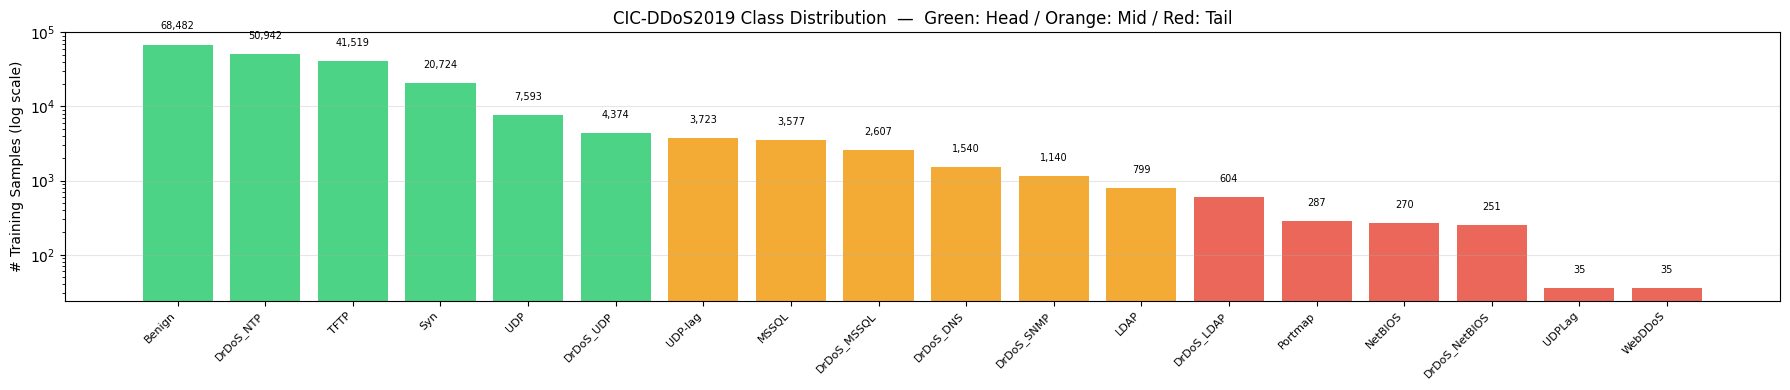

Head (≥3866): 6 classes
Mid  (723–3866): 6 classes
Tail (<723): 6 classes


In [5]:
# Cell 2: Class Distribution Visualization
def visualize_distribution(class_counts, class_names, title, save_path):
    counts = np.array(class_counts)
    order  = np.argsort(counts)[::-1]
    q1, q3 = np.percentile(counts, [33, 66])
    colors = ['#2ecc71' if c >= q3 else '#f39c12' if c >= q1 else '#e74c3c'
              for c in counts[order]]

    fig, ax = plt.subplots(figsize=(max(12, len(class_names)), 4))
    ax.bar(range(len(class_names)), counts[order], color=colors, alpha=0.85)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels([class_names[i] for i in order],
                       rotation=45, ha='right', fontsize=8)
    ax.set_yscale('log')
    ax.set_ylabel('# Training Samples (log scale)')
    ax.set_title(f'{title}  —  Green: Head / Orange: Mid / Red: Tail')
    ax.grid(True, alpha=0.3, axis='y')
    for i, c in enumerate(counts[order]):
        ax.text(i, c * 1.5, f'{c:,}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

    q1_val, q3_val = np.percentile(counts, [33, 66])
    head = sum(1 for c in counts if c >= q3_val)
    mid  = sum(1 for c in counts if q1_val <= c < q3_val)
    tail = sum(1 for c in counts if c < q1_val)
    print(f'Head (≥{q3_val:.0f}): {head} classes')
    print(f'Mid  ({q1_val:.0f}–{q3_val:.0f}): {mid} classes')
    print(f'Tail (<{q1_val:.0f}): {tail} classes')

visualize_distribution(
    class_counts, CLASS_NAMES,
    'CIC-DDoS2019 Class Distribution',
    f'{RESULTS_DIR}/class_distribution.png'
)

In [6]:
# Cell 3: MLP Model + Evaluation Functions

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes,
                 hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def build_mlp():
    return MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)


def compute_metrics(model, loader, class_counts):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            preds = model(X_b.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_b.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    labels = list(range(NUM_CLASSES))
    per_f1 = f1_score(y_true, y_pred, average=None, labels=labels, zero_division=0)

    counts = np.array(class_counts)
    q1, q3 = np.percentile(counts, [33, 66])
    head_idx = [i for i in range(NUM_CLASSES) if counts[i] >= q3]
    mid_idx  = [i for i in range(NUM_CLASSES) if q1 <= counts[i] < q3]
    tail_idx = [i for i in range(NUM_CLASSES) if counts[i] < q1]

    return {
        'Accuracy':          float(accuracy_score(y_true, y_pred)),
        'Balanced_Accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'F1_Macro':          float(f1_score(y_true, y_pred, average='macro',    zero_division=0)),
        'F1_Weighted':       float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'Per_Class_F1':      per_f1.tolist(),
        'Head_F1': float(per_f1[head_idx].mean()) if head_idx else 0.0,
        'Mid_F1':  float(per_f1[mid_idx].mean())  if mid_idx  else 0.0,
        'Tail_F1': float(per_f1[tail_idx].mean()) if tail_idx else 0.0,
    }

print('✓ MLP and evaluation functions defined')

✓ MLP and evaluation functions defined


In [7]:
# Cell 4: train_model() — definition only, not executed here

def train_model(loss_name, class_counts, tr_loader, val_loader,
                alpha=1.0, gamma=2.0, epochs=FINAL_EPOCHS):
    model = build_mlp()

    if get_clf_loss is not None:
        criterion = get_clf_loss(loss_name, class_counts, alpha=alpha, gamma=gamma)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=5, factor=0.5, min_lr=1e-6
    )

    history       = {'train_loss': [], 'val_F1_Macro': []}
    best_F1_Macro = 0.0
    best_state    = None

    print(f"\n{'='*50}\nTraining {loss_name.upper()} "
          f"(α={alpha:.2f}, γ={gamma:.2f})\n{'='*50}")

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            logits   = model(X_b)
            loss     = criterion(logits, y_b)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1

        avg_loss = epoch_loss / max(n_batches, 1)
        history['train_loss'].append(avg_loss)

        metrics  = compute_metrics(model, val_loader, class_counts)
        f1_macro = metrics['F1_Macro']
        history['val_F1_Macro'].append(f1_macro)
        scheduler.step(f1_macro)

        if f1_macro > best_F1_Macro:
            best_F1_Macro = f1_macro
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | '
                  f'F1-Macro: {f1_macro:.4f}')

    if best_state is not None:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    print(f'✓ {loss_name.upper()} best F1-Macro: {best_F1_Macro:.4f}')
    return model, history, best_F1_Macro

print('✓ train_model defined (not executed yet)')

✓ train_model defined (not executed yet)


In [8]:
# Cell 5: Optuna Hyperparameter Search
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['TQDM_DISABLE'] = '1'

def _make_proxy_loader(ratio=PROXY_SUBSET_RATIO):
    n   = int(len(train_loader.dataset) * ratio)
    idx = np.random.choice(len(train_loader.dataset), n, replace=False)
    return DataLoader(Subset(train_loader.dataset, idx),
                     batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

def _cleanup(model=None):
    if model is not None:
        del model
    gc.collect()
    torch.cuda.empty_cache()

print(f'Optuna search (proxy: {PROXY_EPOCHS} epochs, {PROXY_SUBSET_RATIO*100:.0f}% subset)\n')
optuna_best  = {}
proxy_loader = _make_proxy_loader()

# ── PWCE: alpha [0.5, 5.0] ────────────────────────────────────────
N_PWCE = 20
study_pwce = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'alpha': np.linspace(0.5, 5.0, N_PWCE).tolist()})
)
def obj_pwce(trial):
    alpha = trial.suggest_float('alpha', 0.5, 5.0)
    model, _, score = train_model('pwce', class_counts, proxy_loader, val_loader,
                                  alpha=alpha, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_pwce.optimize(obj_pwce, n_trials=N_PWCE)
best_pwce = study_pwce.best_params
optuna_best['pwce'] = best_pwce
print(f'✓ PWCE  best: alpha={best_pwce["alpha"]:.2f}  (F1-Macro={study_pwce.best_value:.4f})')

# ── PLWCE: alpha [1.0, 10.0] ─────────────────────────────────────
N_PLWCE = 20
study_plwce = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'alpha': np.linspace(1.0, 10.0, N_PLWCE).tolist()})
)
def obj_plwce(trial):
    alpha = trial.suggest_float('alpha', 1.0, 10.0)
    model, _, score = train_model('plwce', class_counts, proxy_loader, val_loader,
                                  alpha=alpha, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_plwce.optimize(obj_plwce, n_trials=N_PLWCE)
best_plwce = study_plwce.best_params
optuna_best['plwce'] = best_plwce
print(f'✓ PLWCE best: alpha={best_plwce["alpha"]:.2f}  (F1-Macro={study_plwce.best_value:.4f})')

# ── FOCAL: gamma [0.5, 5.0] ──────────────────────────────────────
N_FOCAL = 20
study_focal = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'gamma': np.linspace(0.5, 5.0, N_FOCAL).tolist()})
)
def obj_focal(trial):
    gamma = trial.suggest_float('gamma', 0.5, 5.0)
    model, _, score = train_model('focal', class_counts, proxy_loader, val_loader,
                                  gamma=gamma, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_focal.optimize(obj_focal, n_trials=N_FOCAL)
best_focal = study_focal.best_params
optuna_best['focal'] = best_focal
print(f'✓ FOCAL best: gamma={best_focal["gamma"]:.2f}  (F1-Macro={study_focal.best_value:.4f})')

print(f'\nOptuna Results:\n{json.dumps(optuna_best, indent=2)}')

Optuna search (proxy: 10 epochs, 20% subset)


Training PWCE (α=4.76, γ=2.00)
Epoch 10/10 | Loss: 1.0308 | F1-Macro: 0.0140
✓ PWCE best F1-Macro: 0.0351

Training PWCE (α=0.74, γ=2.00)
Epoch 10/10 | Loss: 0.8612 | F1-Macro: 0.4113
✓ PWCE best F1-Macro: 0.4193

Training PWCE (α=5.00, γ=2.00)
Epoch 10/10 | Loss: 1.0587 | F1-Macro: 0.0034
✓ PWCE best F1-Macro: 0.0209

Training PWCE (α=2.39, γ=2.00)
Epoch 10/10 | Loss: 1.2279 | F1-Macro: 0.0335
✓ PWCE best F1-Macro: 0.0376

Training PWCE (α=2.87, γ=2.00)
Epoch 10/10 | Loss: 1.1852 | F1-Macro: 0.0133
✓ PWCE best F1-Macro: 0.0263

Training PWCE (α=4.53, γ=2.00)
Epoch 10/10 | Loss: 1.1943 | F1-Macro: 0.0055
✓ PWCE best F1-Macro: 0.0085

Training PWCE (α=1.92, γ=2.00)
Epoch 10/10 | Loss: 1.3434 | F1-Macro: 0.0364
✓ PWCE best F1-Macro: 0.0659

Training PWCE (α=3.58, γ=2.00)
Epoch 10/10 | Loss: 1.1483 | F1-Macro: 0.0101
✓ PWCE best F1-Macro: 0.0318

Training PWCE (α=1.45, γ=2.00)
Epoch 10/10 | Loss: 1.4414 | F1-Macro: 0.3215
✓ PWCE best F1-Macro

In [11]:
# Cell 6: Full Experiment (N_SEEDS seeds)
import random

N_SEEDS       = 5
LOSS_CONFIGS  = ['ce', 'wce', 'pwce', 'lwce', 'plwce', 'cb', 'focal']
seed_results   = {ln: [] for ln in LOSS_CONFIGS}
seed_histories = {ln: [] for ln in LOSS_CONFIGS}

print(f"\n{'='*60}")
print(f'FULL EXPERIMENT: {FINAL_EPOCHS} epochs × {len(LOSS_CONFIGS)} losses × {N_SEEDS} seeds')
print(f"{'='*60}")

for seed in range(N_SEEDS):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print(f"\n{'─'*25}  Seed {seed}  {'─'*25}")

    for loss_name in LOSS_CONFIGS:
        alpha = optuna_best.get(loss_name, {}).get('alpha', 1.0)
        gamma = optuna_best.get('focal', {}).get('gamma', 2.0) if loss_name == 'focal' else 2.0

        model, history, _ = train_model(
            loss_name, class_counts, train_loader, val_loader,
            alpha=alpha, gamma=gamma, epochs=FINAL_EPOCHS
        )
        metrics = compute_metrics(model, test_loader, class_counts)
        seed_results[loss_name].append(metrics)
        seed_histories[loss_name].append(history)
        _cleanup(model)

print(f"\n{'='*60}")
print('✓ Full experiment completed!')
print(f"{'='*60}")


FULL EXPERIMENT: 50 epochs × 7 losses × 5 seeds

─────────────────────────  Seed 0  ─────────────────────────

Training CE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 0.1714 | F1-Macro: 0.4172
Epoch 20/50 | Loss: 0.1642 | F1-Macro: 0.3790
Epoch 30/50 | Loss: 0.1550 | F1-Macro: 0.4327
Epoch 40/50 | Loss: 0.1505 | F1-Macro: 0.4286
Epoch 50/50 | Loss: 0.1492 | F1-Macro: 0.4339
✓ CE best F1-Macro: 0.4566

Training WCE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 1.0754 | F1-Macro: 0.4432
Epoch 20/50 | Loss: 1.0226 | F1-Macro: 0.4714
Epoch 30/50 | Loss: 0.9700 | F1-Macro: 0.4693
Epoch 40/50 | Loss: 0.9484 | F1-Macro: 0.4883
Epoch 50/50 | Loss: 0.9326 | F1-Macro: 0.4844
✓ WCE best F1-Macro: 0.4883

Training PWCE (α=0.50, γ=2.00)
Epoch 10/50 | Loss: 0.5030 | F1-Macro: 0.4399
Epoch 20/50 | Loss: 0.4752 | F1-Macro: 0.4082
Epoch 30/50 | Loss: 0.4624 | F1-Macro: 0.4306
Epoch 40/50 | Loss: 0.4567 | F1-Macro: 0.4971
Epoch 50/50 | Loss: 0.4555 | F1-Macro: 0.4950
✓ PWCE best F1-Macro: 0.4985

Training LWCE (α=1.00


EXPERIMENT SUMMARY (mean ± std, N=5)
Loss                Bal_Acc           F1_Macro            Head_F1            Tail_F1
ce            0.4984±0.0036      0.4515±0.0051      0.7848±0.0004      0.1170±0.0161
wce           0.6012±0.0088      0.4938±0.0019      0.8064±0.0074      0.2026±0.0084
pwce          0.5686±0.0059      0.5015±0.0030      0.7851±0.0006      0.2106±0.0302
lwce          0.5266±0.0032      0.4841±0.0075      0.7852±0.0003      0.1941±0.0164
plwce         0.5641±0.0091      0.4922±0.0047      0.7843±0.0004      0.2102±0.0221
cb            0.5760±0.0017      0.5026±0.0040      0.7870±0.0022      0.2539±0.0105
focal         0.5057±0.0035      0.4568±0.0045      0.7851±0.0002      0.1267±0.0125


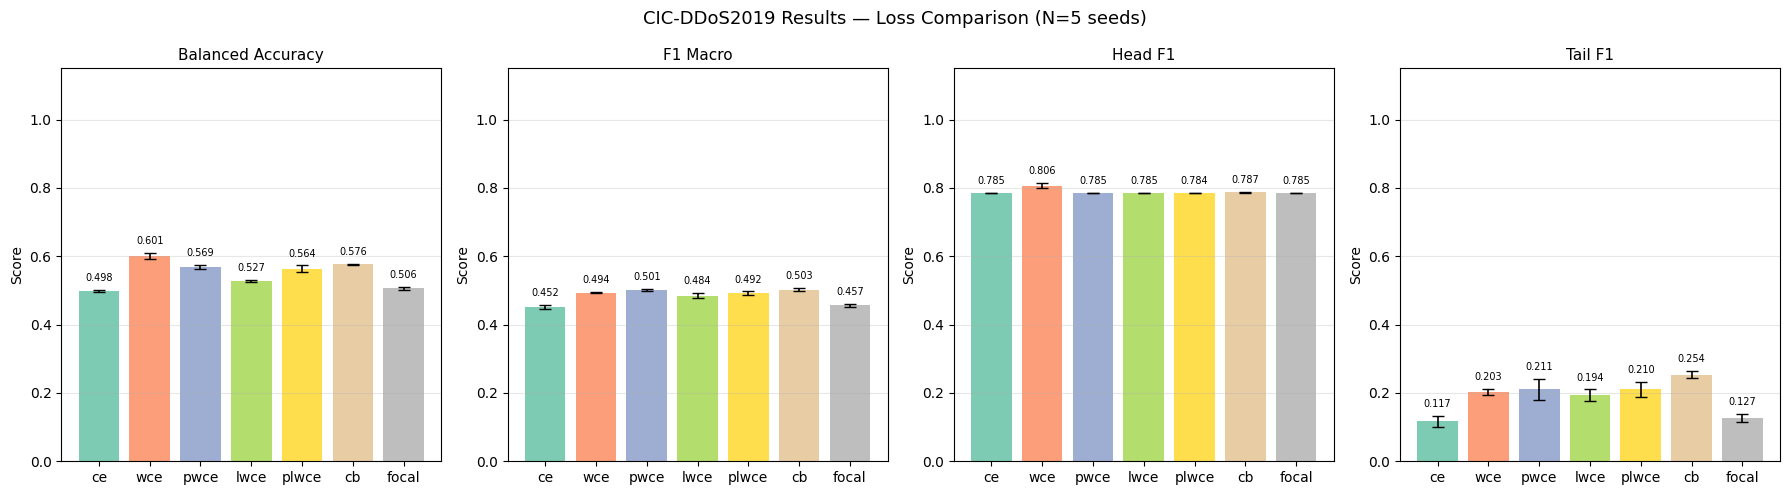

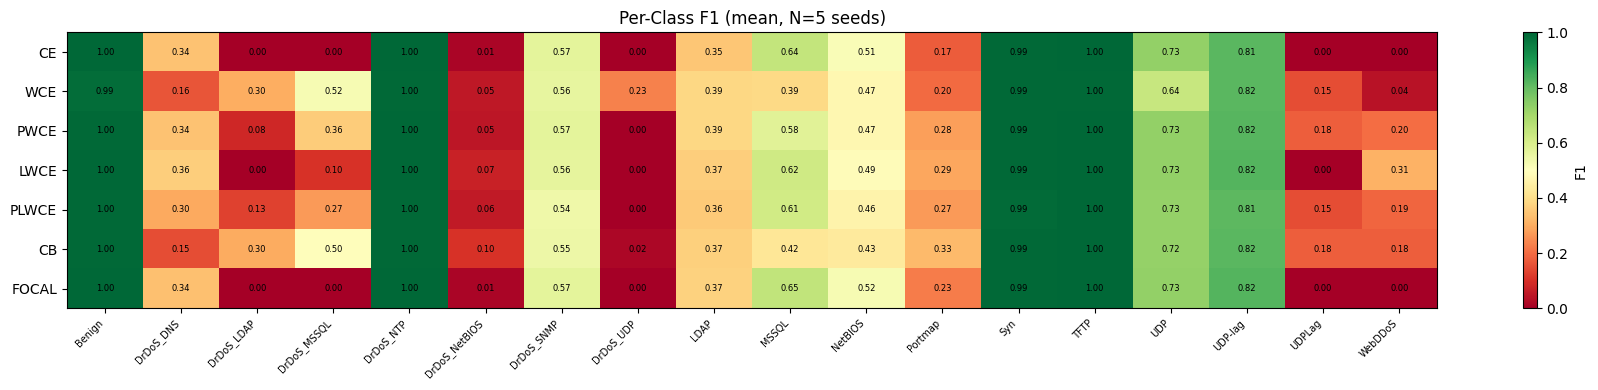

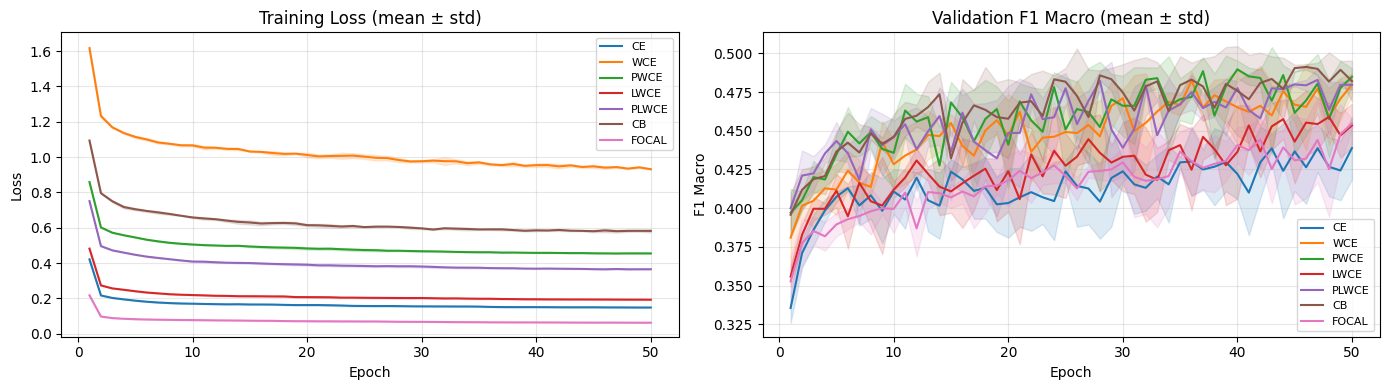

✓ Saved JSON
✓ Saved Excel

FINAL SUMMARY (mean ± std, N=5)
 Loss Balanced_Accuracy      F1_Macro       Head_F1       Tail_F1
   ce     0.4984±0.0036 0.4515±0.0051 0.7848±0.0004 0.1170±0.0161
  wce     0.6012±0.0088 0.4938±0.0019 0.8064±0.0074 0.2026±0.0084
 pwce     0.5686±0.0059 0.5015±0.0030 0.7851±0.0006 0.2106±0.0302
 lwce     0.5266±0.0032 0.4841±0.0075 0.7852±0.0003 0.1941±0.0164
plwce     0.5641±0.0091 0.4922±0.0047 0.7843±0.0004 0.2102±0.0221
   cb     0.5760±0.0017 0.5026±0.0040 0.7870±0.0022 0.2539±0.0105
focal     0.5057±0.0035 0.4568±0.0045 0.7851±0.0002 0.1267±0.0125


In [12]:
# Cell 7: Aggregate + Visualize + Save Results
METRIC_KEYS = ['Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Mid_F1', 'Tail_F1', 'Accuracy', 'F1_Weighted']
loss_names  = LOSS_CONFIGS

# ── Aggregate mean ± std ──────────────────────────────────────────
agg = {}
for ln in loss_names:
    agg[ln] = {}
    for k in METRIC_KEYS:
        vals = [r[k] for r in seed_results[ln]]
        agg[ln][k] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals))}
    per_cls_all = np.array([r['Per_Class_F1'] for r in seed_results[ln]])
    agg[ln]['Per_Class_F1_mean'] = per_cls_all.mean(axis=0).tolist()
    agg[ln]['Per_Class_F1_std']  = per_cls_all.std(axis=0).tolist()

# ── Summary print ─────────────────────────────────────────────────
def ms(ln, k): return f"{agg[ln][k]['mean']:.4f}±{agg[ln][k]['std']:.4f}"

print(f"\n{'='*60}\nEXPERIMENT SUMMARY (mean ± std, N={N_SEEDS})\n{'='*60}")
W = 17
print(f"{'Loss':8s}  {'Bal_Acc':>{W}}  {'F1_Macro':>{W}}  {'Head_F1':>{W}}  {'Tail_F1':>{W}}")
for ln in loss_names:
    print(f"{ln:8s}  {ms(ln,'Balanced_Accuracy'):>{W}}  {ms(ln,'F1_Macro'):>{W}}  {ms(ln,'Head_F1'):>{W}}  {ms(ln,'Tail_F1'):>{W}}")

# ── Bar chart with error bars ─────────────────────────────────────
colors = plt.cm.Set2(np.linspace(0, 1, len(loss_names)))
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'{DATASET_NAME} Results — Loss Comparison (N={N_SEEDS} seeds)', fontsize=13)
for ax, key, title in zip(
    axes,
    ['Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Tail_F1'],
    ['Balanced Accuracy',  'F1 Macro', 'Head F1', 'Tail F1']
):
    means = [agg[ln][key]['mean'] for ln in loss_names]
    stds  = [agg[ln][key]['std']  for ln in loss_names]
    bars  = ax.bar(loss_names, means, color=colors, alpha=0.85)
    ax.errorbar(loss_names, means, yerr=stds,
                fmt='none', color='black', capsize=4, linewidth=1.2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.15)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.02,
                f'{m:.3f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class F1 heatmap (mean over seeds) ────────────────────────
per_cls_mat = np.array([agg[ln]['Per_Class_F1_mean'] for ln in loss_names])
fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES), 4))
im = ax.imshow(per_cls_mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(loss_names)))
ax.set_yticklabels([ln.upper() for ln in loss_names])
ax.set_title(f'Per-Class F1 (mean, N={N_SEEDS} seeds)')
plt.colorbar(im, ax=ax, label='F1')
for i in range(len(loss_names)):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{per_cls_mat[i,j]:.2f}', ha='center', va='center', fontsize=6)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Training curves (mean ± std band) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_x = np.arange(1, FINAL_EPOCHS + 1)
for ln in loss_names:
    loss_arr = np.array([h['train_loss']   for h in seed_histories[ln]])
    f1_arr   = np.array([h['val_F1_Macro'] for h in seed_histories[ln]])
    for ax, arr in zip(axes, [loss_arr, f1_arr]):
        m, s = arr.mean(axis=0), arr.std(axis=0)
        line, = ax.plot(epochs_x, m, label=ln.upper())
        ax.fill_between(epochs_x, m - s, m + s, alpha=0.15, color=line.get_color())
for ax, title, ylabel in zip(axes,
    ['Training Loss (mean ± std)', 'Validation F1 Macro (mean ± std)'],
    ['Loss', 'F1 Macro']):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save JSON ─────────────────────────────────────────────────────
fname = DATASET_NAME.lower().replace('-', '').replace(' ', '_')
results_json = {
    'metadata': {
        'dataset':      DATASET_NAME,
        'model':        'MLP (256-128-64, BatchNorm, Dropout=0.3)',
        'num_classes':  NUM_CLASSES,
        'class_names':  CLASS_NAMES,
        'final_epochs': FINAL_EPOCHS,
        'batch_size':   BATCH_SIZE,
        'n_seeds':      N_SEEDS,
        'optuna_best':  optuna_best,
        'class_counts': class_counts,
    },
    'aggregated': agg,
    'per_seed':   {ln: seed_results[ln] for ln in loss_names},
}
with open(f'{RESULTS_DIR}/{fname}_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)
print('✓ Saved JSON')

# ── Save Excel ────────────────────────────────────────────────────
summary_rows = []
for ln in loss_names:
    row = {'Loss': ln}
    for k in METRIC_KEYS:
        row[f'{k}_mean'] = round(agg[ln][k]['mean'], 4)
        row[f'{k}_std']  = round(agg[ln][k]['std'],  4)
        row[k]           = f"{agg[ln][k]['mean']:.4f}±{agg[ln][k]['std']:.4f}"
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)

per_class_df = pd.DataFrame(
    {ln: agg[ln]['Per_Class_F1_mean'] for ln in loss_names},
    index=CLASS_NAMES
)

raw_rows = []
for ln in loss_names:
    for s, r in enumerate(seed_results[ln]):
        row = {'loss': ln, 'seed': s}
        for k in METRIC_KEYS:
            row[k] = r[k]
        raw_rows.append(row)

with pd.ExcelWriter(f'{RESULTS_DIR}/{fname}_results.xlsx', engine='openpyxl') as writer:
    summary_df.to_excel(writer,   sheet_name='Summary_MeanStd',  index=False)
    per_class_df.to_excel(writer, sheet_name='Per_Class_F1_Mean')
    pd.DataFrame(raw_rows).to_excel(writer, sheet_name='Per_Seed_Raw', index=False)
print('✓ Saved Excel')

print(f"\n{'='*60}\nFINAL SUMMARY (mean ± std, N={N_SEEDS})\n{'='*60}")
disp = ['Loss', 'Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Tail_F1']
print(summary_df[disp].to_string(index=False))